# 01 — Data Collection
## SMNA2026 Assignment 2: Public Sentiment Toward Electric Vehicles in Australia

**Team:** Ansh Anand Parekh (s4060237), Disha Dogra (s4091900), Syna Arora (s4109652)

**Data Source:** Reddit Public JSON API — No API key required

### Subreddits:
- r/australia — General Australian EV opinions
- r/ausEV — Dedicated Australian EV community
- r/AusFinance — EV cost discussions
- r/electricvehicles — Broader EV discussions

## 1. Import Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import os
from datetime import datetime, timezone
from tqdm import tqdm
import matplotlib.pyplot as plt

print('Libraries imported!')
print(f'Pandas : {pd.__version__}')
print(f'NumPy  : {np.__version__}')

Libraries imported!
Pandas : 3.0.2
NumPy  : 2.2.6


## 2. Configuration

In [2]:
# Date range
DATE_START = '2023-01-01'
DATE_END   = '2025-12-31'

DATE_START_TS = int(datetime(2023, 1, 1, tzinfo=timezone.utc).timestamp())
DATE_END_TS   = int(datetime(2025, 12, 31, tzinfo=timezone.utc).timestamp())

# Subreddits to collect
# ev_filter=True  -> only keep EV-related posts
# ev_filter=False -> keep all posts (already EV focused)
SUBREDDITS = {
    'ausEV'           : {'ev_filter': False, 'target': 500},
    'australia'       : {'ev_filter': True,  'target': 500},
    'AusFinance'      : {'ev_filter': True,  'target': 300},
    'electricvehicles': {'ev_filter': True,  'target': 300}
}

# EV keywords for filtering general subreddits
EV_KEYWORDS = [
    'electric vehicle', 'electric car', 'EV ', ' EVs', ' EV,',
    'tesla', 'charging station', 'battery range', 'BEV', 'PHEV',
    'hybrid electric', 'zero emission', 'ausEV', 'MG ZS', 'BYD',
    'Nissan Leaf', 'Hyundai Ioniq', 'Kia EV', 'range anxiety',
    'charging infrastructure', 'home charging', 'fast charger',
    'model 3', 'model y', 'model s', 'ev rebate', 'ev subsidy',
    'electric ute', 'electric truck', 'powerwall', 'ev charging',
    'charge point', 'supercharger', 'wallbox', 'ioniq', 'polestar',
    'rivian', 'lucid', 'zeekr', 'chery', 'atto', 'seal', 'dolphin'
]

# Reddit public JSON headers
HEADERS = {
    'User-Agent': 'Mozilla/5.0 RMIT-Research/1.0 EV-Sentiment-Study'
}

# Output directories
RAW_DIR       = '../data/raw/'
PROCESSED_DIR = '../data/processed/'
SAMPLE_DIR    = '../data/sample/'
FIGURES_DIR   = '../reports/figures/'

for d in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Configuration ready!')
print(f'Date range : {DATE_START} to {DATE_END}')
print(f'Subreddits : {", ".join(["r/"+s for s in SUBREDDITS])}')
print(f'EV keywords: {len(EV_KEYWORDS)} defined')

Configuration ready!
Date range : 2023-01-01 to 2025-12-31
Subreddits : r/ausEV, r/australia, r/AusFinance, r/electricvehicles
EV keywords: 43 defined


## 3. Helper Functions

In [3]:
def unix_to_dt(ts):
    """Convert Unix timestamp to readable datetime string."""
    try:
        return datetime.fromtimestamp(float(ts), tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S')
    except:
        return ''


def is_ev_related(text):
    """Return True if text contains any EV keyword."""
    if not isinstance(text, str):
        return False
    t = text.lower()
    return any(kw.lower() in t for kw in EV_KEYWORDS)


def is_in_date_range(ts):
    """Return True if Unix timestamp falls within our date range."""
    try:
        return DATE_START_TS <= float(ts) <= DATE_END_TS
    except:
        return False


def safe_reddit_request(url, params=None, retries=3):
    """
    Make a safe request to Reddit public JSON API.
    Handles rate limiting and errors gracefully.
    """
    for attempt in range(retries):
        try:
            r = requests.get(
                url,
                params=params,
                headers=HEADERS,
                timeout=30
            )
            if r.status_code == 200:
                return r.json()
            elif r.status_code == 429:
                wait = 60
                print(f'  Rate limited — waiting {wait}s...')
                time.sleep(wait)
            elif r.status_code == 403:
                print(f'  403 Forbidden — subreddit may be private')
                return None
            else:
                print(f'  HTTP {r.status_code} attempt {attempt+1}/{retries}')
                time.sleep(5)
        except Exception as e:
            print(f'  Error attempt {attempt+1}: {e}')
            time.sleep(5)
    return None


def parse_post(post_data, subreddit):
    """Extract relevant fields from a Reddit post."""
    p = post_data.get('data', post_data)
    return {
        'post_id'      : p.get('id', ''),
        'title'        : p.get('title', ''),
        'selftext'     : p.get('selftext', ''),
        'score'        : p.get('score', 0),
        'upvote_ratio' : p.get('upvote_ratio', 0),
        'num_comments' : p.get('num_comments', 0),
        'author'       : p.get('author', '[deleted]'),
        'created_utc'  : p.get('created_utc', 0),
        'created_dt'   : unix_to_dt(p.get('created_utc', 0)),
        'subreddit'    : subreddit,
        'url'          : p.get('url', ''),
        'permalink'    : f'https://reddit.com{p.get("permalink", "")}'
    }


print('Helper functions ready!')

Helper functions ready!


## 4. Test API Connection

In [4]:
# Always test before full collection
print('Testing Reddit public JSON API...')
print('-' * 40)

test = safe_reddit_request(
    'https://www.reddit.com/r/ausEV/new.json',
    params={'limit': 5}
)

if test:
    posts = test.get('data', {}).get('children', [])
    print(f'API working! Got {len(posts)} posts')
    for p in posts:
        d = p.get('data', {})
        print(f'  - {d.get("title", "")[:60]}')
        print(f'    Date: {unix_to_dt(d.get("created_utc", 0))}')
    print('\nReady to collect!')
else:
    print('API test failed — check internet connection')

Testing Reddit public JSON API...
----------------------------------------
API working! Got 7 posts
  - Gaming Region Stuttgart | Alles Rund um Gaming und eSport
    Date: 2017-12-12 09:42:40
  - ApexLegendsDE
    Date: 2021-05-06 15:49:51
  - Australian Electric Vehicles
    Date: 2014-08-04 13:55:03
  - Electric Vehicle News and Discussion
    Date: 2009-04-20 22:40:11
  - Mental Health &amp; Well Being in Australia.
    Date: 2019-05-25 07:18:51
  - c-base - the mothership of hackerspaces
    Date: 2012-09-04 15:21:12
  - SV Darmstadt 98
    Date: 2014-09-16 21:50:11

Ready to collect!


## 5. Step 1 — Collect Posts

We use Reddit's public JSON API with pagination.
Reddit allows browsing by: new, hot, top, rising — no auth needed.
We paginate using the 'after' cursor Reddit provides in each response.

In [5]:
def collect_posts_from_subreddit(subreddit, target=500, ev_filter=True):
    """
    Collect posts from a subreddit using Reddit public JSON API.
    Paginates through new, top (year), top (all) to maximise data.
    Filters by date range and EV keywords.
    """
    all_posts = []
    seen_ids  = set()

    print(f'\nCollecting r/{subreddit} (target={target}, ev_filter={ev_filter})...')

    # Use multiple sort methods to get more data
    endpoints = [
        f'https://www.reddit.com/r/{subreddit}/new.json',
        f'https://www.reddit.com/r/{subreddit}/top.json?t=year',
        f'https://www.reddit.com/r/{subreddit}/top.json?t=all',
        f'https://www.reddit.com/r/{subreddit}/hot.json'
    ]

    for endpoint in endpoints:
        if len(all_posts) >= target:
            break

        after      = None
        no_new     = 0
        page_count = 0

        while len(all_posts) < target:
            params = {'limit': 100, 'raw_json': 1}
            if after:
                params['after'] = after

            data = safe_reddit_request(endpoint, params)

            if not data:
                break

            children = data.get('data', {}).get('children', [])
            if not children:
                break

            added = 0
            for child in children:
                p   = child.get('data', {})
                pid = p.get('id', '')
                utc = p.get('created_utc', 0)

                # Skip duplicates
                if pid in seen_ids:
                    continue
                seen_ids.add(pid)

                # Date filter
                if not is_in_date_range(utc):
                    continue

                # EV keyword filter
                title = p.get('title', '')
                body  = p.get('selftext', '')
                if ev_filter and not is_ev_related(title + ' ' + body):
                    continue

                all_posts.append(parse_post(child, subreddit))
                added += 1

                if len(all_posts) >= target:
                    break

            page_count += 1
            after = data.get('data', {}).get('after')

            print(f'  Page {page_count}: fetched={len(children)}, kept={added}, total={len(all_posts)}')

            if not after or added == 0:
                no_new += 1
            else:
                no_new = 0

            # Stop if no new posts for 3 consecutive pages
            if no_new >= 3:
                break

            # Polite delay
            time.sleep(2)

    print(f'  -> Total: {len(all_posts)} posts from r/{subreddit}')
    return all_posts


print('collect_posts_from_subreddit() ready!')

collect_posts_from_subreddit() ready!


In [6]:
# Collect from ALL subreddits
all_posts = []
seen_ids  = set()

print('Starting post collection...')
print('=' * 60)

for subreddit, cfg in SUBREDDITS.items():
    posts = collect_posts_from_subreddit(
        subreddit = subreddit,
        target    = cfg['target'],
        ev_filter = cfg['ev_filter']
    )
    # Global deduplication
    new = [p for p in posts if p['post_id'] not in seen_ids]
    seen_ids.update(p['post_id'] for p in new)
    all_posts.extend(new)
    print(f'  Running total: {len(all_posts)} posts\n')

print('=' * 60)

if not all_posts:
    print('ERROR: No posts collected!')
else:
    posts_df = pd.DataFrame(all_posts).reset_index(drop=True)
    print(f'TOTAL UNIQUE POSTS: {len(posts_df)}')
    print(f'\nBy subreddit:')
    print(posts_df['subreddit'].value_counts())
    print(f'\nDate range:')
    print(f'  Earliest: {posts_df["created_dt"].min()}')
    print(f'  Latest  : {posts_df["created_dt"].max()}')

Starting post collection...

  Page 1: fetched=7, kept=0, total=0
  Page 2: fetched=7, kept=0, total=0
  Page 3: fetched=7, kept=0, total=0
  Page 1: fetched=7, kept=0, total=0
  Page 2: fetched=7, kept=0, total=0
  Page 3: fetched=7, kept=0, total=0
  Page 1: fetched=7, kept=0, total=0
  Page 2: fetched=7, kept=0, total=0
  Page 3: fetched=7, kept=0, total=0
  Page 1: fetched=7, kept=0, total=0
  Page 2: fetched=7, kept=0, total=0
  Page 3: fetched=7, kept=0, total=0
  -> Total: 0 posts from r/ausEV
  Running total: 0 posts


  Page 1: fetched=100, kept=0, total=0
  Page 2: fetched=100, kept=0, total=0
  Page 3: fetched=100, kept=0, total=0
  Page 1: fetched=100, kept=0, total=0
  Page 2: fetched=100, kept=1, total=1
  Page 3: fetched=100, kept=0, total=1
  Page 4: fetched=100, kept=1, total=2
  Page 5: fetched=98, kept=0, total=2
  Page 6: fetched=100, kept=0, total=2
  Page 7: fetched=100, kept=0, total=2
  Page 1: fetched=100, kept=0, total=2
  Page 2: fetched=100, kept=0, total=2


In [7]:
# Preview sample posts
print('Sample posts:')
for _, row in posts_df.head(5).iterrows():
    print(f'  [{row["subreddit"]}] {row["title"][:70]}')
    print(f'    Score: {row["score"]} | Comments: {row["num_comments"]} | Date: {row["created_dt"][:10]}')
    print()

print('\nScore statistics:')
print(posts_df['score'].describe().round(1))

Sample posts:
  [australia] David Stratton, film critic and host of At the Movies alongside Margar
    Score: 3323 | Comments: 271 | Date: 2025-08-14

  [australia] Antoinette Lattouf wins unlawful termination case against the ABC as f
    Score: 1824 | Comments: 275 | Date: 2025-06-25

  [AusFinance] The surprising economics of switching to an all electric household.
    Score: 638 | Comments: 236 | Date: 2025-06-02

  [AusFinance] How Your Novated Lease Company Might Be Conning You
    Score: 546 | Comments: 103 | Date: 2025-06-22

  [AusFinance] Novated Lease Companies Hate This Updated Spreadsheet: How a 7.8% Quot
    Score: 408 | Comments: 71 | Date: 2025-11-02


Score statistics:
count      311.0
mean      1583.9
std       1588.5
min        334.0
25%        667.5
50%       1017.0
75%       1943.5
max      19256.0
Name: score, dtype: float64


In [8]:
# Save raw posts
posts_path = os.path.join(RAW_DIR, 'posts.csv')
posts_df.to_csv(posts_path, index=False)
print(f'Posts saved : {posts_path}')
print(f'Size        : {os.path.getsize(posts_path)/1024:.1f} KB')
print(f'Total posts : {len(posts_df)}')

Posts saved : ../data/raw/posts.csv
Size        : 233.2 KB
Total posts : 311


## 6. Step 2 — Collect Comments

For each post we collect all comments using Reddit's comment JSON endpoint.
- `parent_id` → who replied to whom → builds our network graph
- `body` → text content → NLP sentiment analysis
- `author` → network nodes → find influential users
- `created_utc` → timestamps → track discussion over time

In [9]:
def parse_comments_recursive(comments_data, post_id, subreddit, all_comments):
    """
    Recursively parse Reddit comment trees.
    Reddit nests replies inside each comment — we flatten them.
    """
    if not comments_data:
        return

    for item in comments_data:
        kind = item.get('kind', '')
        data = item.get('data', {})

        # Skip 'more' objects (load more links)
        if kind == 'more':
            continue

        if kind == 't1':  # t1 = comment
            pid = data.get('parent_id', '')
            all_comments.append({
                'comment_id' : data.get('id', ''),
                'post_id'    : post_id,
                'parent_id'  : pid,
                'is_toplevel': pid.startswith('t3_'),
                'author'     : data.get('author', '[deleted]'),
                'body'       : data.get('body', ''),
                'score'      : data.get('score', 0),
                'created_utc': data.get('created_utc', 0),
                'created_dt' : unix_to_dt(data.get('created_utc', 0)),
                'subreddit'  : subreddit,
                'depth'      : data.get('depth', 0)
            })

            # Recursively get replies
            replies = data.get('replies', '')
            if isinstance(replies, dict):
                reply_children = replies.get('data', {}).get('children', [])
                parse_comments_recursive(reply_children, post_id, subreddit, all_comments)


def collect_comments_for_post(post_id, subreddit, permalink):
    """
    Collect all comments for a Reddit post using public JSON.
    """
    # Build comment URL from permalink
    if permalink.startswith('https://reddit.com'):
        url = permalink.rstrip('/') + '.json'
    else:
        url = f'https://www.reddit.com/r/{subreddit}/comments/{post_id}.json'

    data = safe_reddit_request(url, params={'limit': 500, 'depth': 10, 'raw_json': 1})

    if not data or not isinstance(data, list) or len(data) < 2:
        return []

    # data[0] = post info, data[1] = comments
    comments_data = data[1].get('data', {}).get('children', [])

    all_comments = []
    parse_comments_recursive(comments_data, post_id, subreddit, all_comments)

    return all_comments


# Test on one post
if len(posts_df) > 0:
    test_row      = posts_df.iloc[0]
    test_comments = collect_comments_for_post(
        test_row['post_id'],
        test_row['subreddit'],
        test_row['permalink']
    )
    print(f'Test post    : {test_row["title"][:60]}')
    print(f'Comments got : {len(test_comments)}')
    if test_comments:
        c = test_comments[0]
        print(f'Sample body  : {c["body"][:100]}')
        print(f'Parent ID    : {c["parent_id"]}')
        print(f'Top level    : {c["is_toplevel"]}')
else:
    print('No posts to test with!')

Test post    : David Stratton, film critic and host of At the Movies alongs
Comments got : 244
Sample body  : RIP to a legend.
Parent ID    : t3_1mprh9r
Top level    : True


In [10]:
# Collect comments for ALL posts
all_comments  = []
failed_posts  = []
comments_path = os.path.join(RAW_DIR, 'comments.csv')

print(f'Collecting comments for {len(posts_df)} posts...')
print(f'Est. time: ~{len(posts_df) * 2 / 60:.0f} minutes')
print('-' * 50)

for i, (_, post) in enumerate(tqdm(
    posts_df.iterrows(),
    total=len(posts_df),
    desc='Collecting comments'
)):
    comments = collect_comments_for_post(
        post['post_id'],
        post['subreddit'],
        post['permalink']
    )

    if comments:
        all_comments.extend(comments)
    else:
        failed_posts.append(post['post_id'])

    # Save progress every 50 posts
    if (i + 1) % 50 == 0:
        pd.DataFrame(all_comments).to_csv(comments_path, index=False)
        tqdm.write(f'Progress: {len(all_comments)} comments from {i+1} posts')

    # Polite delay — important to avoid rate limiting
    time.sleep(2)

# Final save
comments_df = pd.DataFrame(all_comments)
comments_df.to_csv(comments_path, index=False)

print(f'\nDone!')
print(f'Total comments     : {len(comments_df)}')
print(f'Posts with comments: {comments_df["post_id"].nunique()}')
print(f'Posts failed       : {len(failed_posts)}')
print(f'Avg per post       : {len(comments_df)/max(len(posts_df),1):.1f}')

Est. time: ~10 minutes
--------------------------------------------------


  Rate limited — waiting 60s...
  Rate limited — waiting 60s...


Progress: 16655 comments from 50 posts


Progress: 30312 comments from 100 posts


  Rate limited — waiting 60s...
  Rate limited — waiting 60s...
  Rate limited — waiting 60s...


...

Progress: 55850 comments from 200 posts


  Rate limited — waiting 60s...
  Rate limited — waiting 60s...
  Rate limited — waiting 60s...


Progress: 73073 comments from 250 posts


Progress: 91110 comments from 300 posts



Done!
Total comments     : 94768
Posts with comments: 309
Posts failed       : 2
Avg per post       : 304.7


## 7. Visualise Collection Results

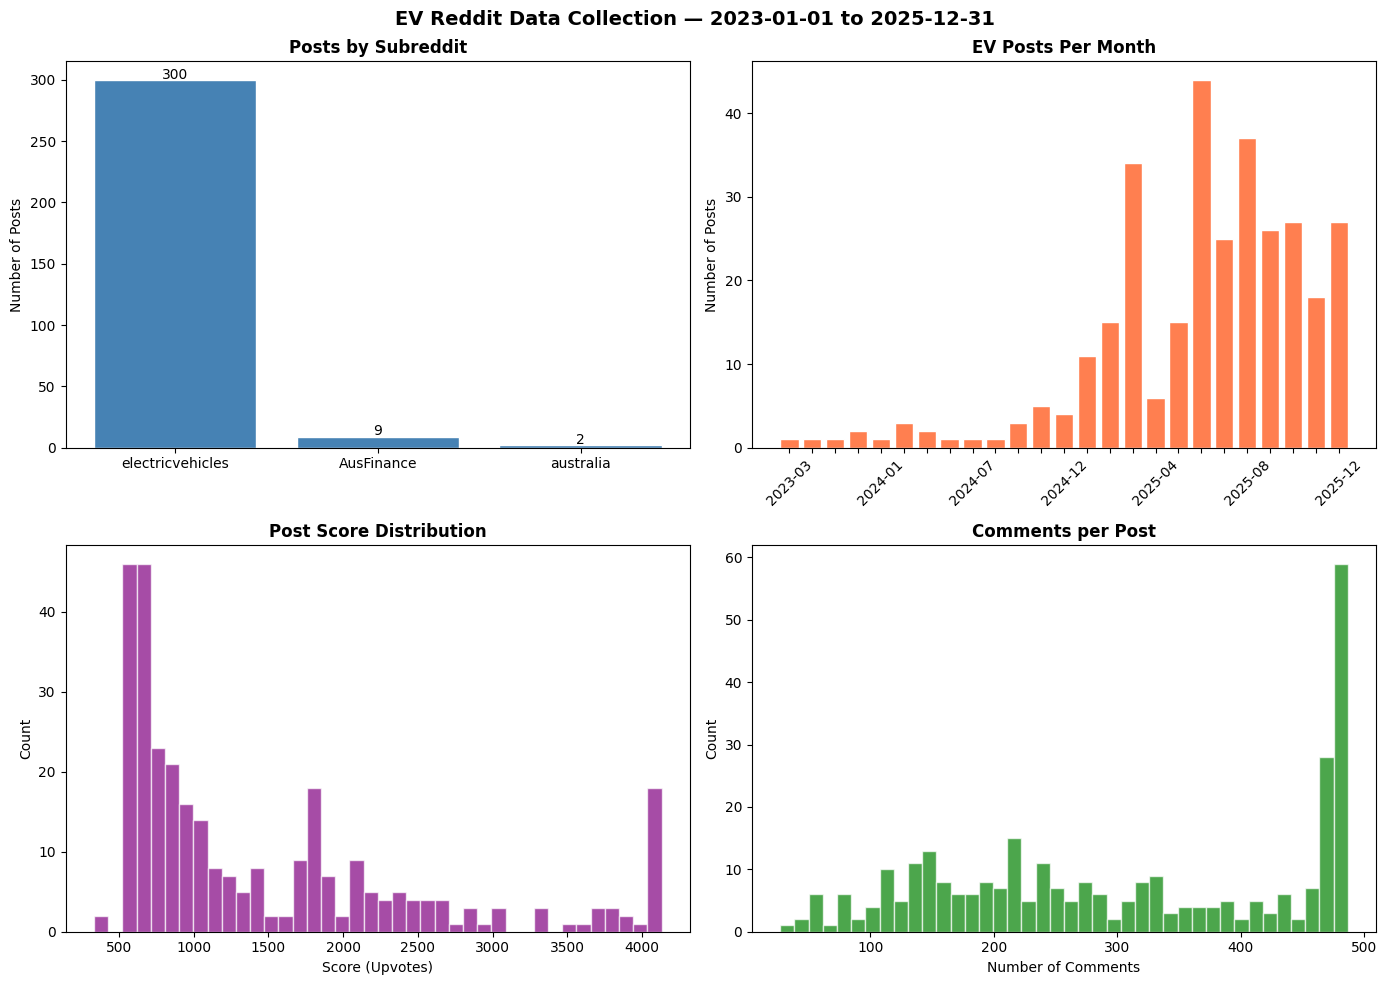

Figure saved to reports/figures/data_collection_overview.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Posts by subreddit
sc = posts_df['subreddit'].value_counts()
axes[0,0].bar(sc.index, sc.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Posts by Subreddit', fontweight='bold')
axes[0,0].set_ylabel('Number of Posts')
for i, v in enumerate(sc.values):
    axes[0,0].text(i, v + 1, str(v), ha='center', fontsize=10)

# Posts over time
posts_df['year_month'] = pd.to_datetime(posts_df['created_dt']).dt.to_period('M').astype(str)
mc = posts_df.groupby('year_month').size().reset_index(name='count')
axes[0,1].bar(mc['year_month'], mc['count'], color='coral', edgecolor='white')
axes[0,1].set_title('EV Posts Per Month', fontweight='bold')
axes[0,1].set_ylabel('Number of Posts')
axes[0,1].tick_params(axis='x', rotation=45)
for i, label in enumerate(axes[0,1].get_xticklabels()):
    if i % 4 != 0:
        label.set_visible(False)

# Score distribution
axes[1,0].hist(
    posts_df['score'].clip(upper=posts_df['score'].quantile(0.95)),
    bins=40, color='purple', alpha=0.7, edgecolor='white'
)
axes[1,0].set_title('Post Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('Score (Upvotes)')
axes[1,0].set_ylabel('Count')

# Comments per post
if len(comments_df) > 0:
    cpp = comments_df.groupby('post_id').size()
    axes[1,1].hist(
        cpp.clip(upper=cpp.quantile(0.95)),
        bins=40, color='green', alpha=0.7, edgecolor='white'
    )
    axes[1,1].set_title('Comments per Post', fontweight='bold')
    axes[1,1].set_xlabel('Number of Comments')
    axes[1,1].set_ylabel('Count')

plt.suptitle(
    f'EV Reddit Data Collection — {DATE_START} to {DATE_END}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'data_collection_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to reports/figures/data_collection_overview.png')

## 8. Save Data Sample for Submission

In [12]:
# Save balanced sample — 100 posts + their comments
sample_posts    = posts_df.head(100)
sample_ids      = sample_posts['post_id'].tolist()
sample_comments = comments_df[comments_df['post_id'].isin(sample_ids)] if len(comments_df) > 0 else pd.DataFrame()

sample_posts.to_csv(os.path.join(SAMPLE_DIR, 'sample_posts.csv'), index=False)
if len(sample_comments) > 0:
    sample_comments.to_csv(os.path.join(SAMPLE_DIR, 'sample_comments.csv'), index=False)

print('Sample data saved:')
for f in ['sample_posts.csv', 'sample_comments.csv']:
    p = os.path.join(SAMPLE_DIR, f)
    if os.path.exists(p):
        size = os.path.getsize(p) / (1024 * 1024)
        print(f'  {f}: {size:.2f} MB')

print(f'\nSample posts   : {len(sample_posts)}')
print(f'Sample comments: {len(sample_comments)}')

Sample data saved:
  sample_posts.csv: 0.08 MB
  sample_comments.csv: 9.64 MB

Sample posts   : 100
Sample comments: 30312


## 9. Final Summary

In [37]:
import pandas as pd
import os

# Load from saved files
posts_df    = pd.read_csv('../data/raw/posts.csv')
comments_df = pd.read_csv('../data/raw/comments.csv')

DATE_START = '2023-01-01'
DATE_END   = '2025-12-31'
SUBREDDITS = ['ausEV', 'australia', 'AusFinance', 'electricvehicles']

print('=' * 60)
print('DATA COLLECTION COMPLETE')
print('=' * 60)
print(f'Date range       : {DATE_START} to {DATE_END}')
print(f'Subreddits       : {", ".join(["r/"+s for s in SUBREDDITS])}')
print(f'Total posts      : {len(posts_df)}')
print(f'Total comments   : {len(comments_df)}')
print(f'Avg comments/post: {len(comments_df)/max(len(posts_df),1):.1f}')
print(f'')
print(f'Posts by subreddit:')
for sub, count in posts_df['subreddit'].value_counts().items():
    print(f'  r/{sub:<20}: {count} posts')
print(f'')
print(f'Files saved:')
print(f'  data/raw/posts.csv')
print(f'  data/raw/comments.csv')
print(f'  data/sample/sample_posts.csv')
print(f'  data/sample/sample_comments.csv')
print(f'  reports/figures/data_collection_overview.png')
print('=' * 60)

DATA COLLECTION COMPLETE
Date range       : 2023-01-01 to 2025-12-31
Subreddits       : r/ausEV, r/australia, r/AusFinance, r/electricvehicles
Total posts      : 311
Total comments   : 94768
Avg comments/post: 304.7

Posts by subreddit:
  r/electricvehicles    : 300 posts
  r/AusFinance          : 9 posts
  r/australia           : 2 posts

Files saved:
  data/raw/posts.csv
  data/raw/comments.csv
  data/sample/sample_posts.csv
  data/sample/sample_comments.csv
  reports/figures/data_collection_overview.png
